<a href="https://colab.research.google.com/github/egor2025slo/credit_card_defalult_prediction/blob/main/Credit_Card_Default_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# For any financial institution, credit default is a primary source of financial loss. This project addresses the critical business need to minimize credit risk by proactively identifying clients who are likely to default on their credit card payments. By accurately predicting potential defaults, the bank can implement targeted interventions, reduce credit losses, and optimize its risk management strategies.
# The goal is to build a binary classification model that predicts whether a client will default on their payment in the upcoming month. This model will be trained on a historical dataset of client information and payment behavior.
# Success Criteria:
# Technical: The model's performance will be evaluated using the F1-Score and AUC-ROC, which are robust metrics for imbalanced classification tasks.
# Business: The ultimate success is the model's ability to effectively segment clients by risk, enabling the bank to minimize financial losses from defaults (**high Recall**) while maintaining a healthy portfolio of creditworthy customers (**high Precision**).

In [6]:
# --- 1. Setup: Importing Libraries and Loading Data ---

# Core libraries for data manipulation and numerical operations
import pandas as pd
import numpy as np

# Libraries for data visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Utility to ignore warnings for a cleaner output
import warnings
warnings.filterwarnings('ignore')

# --- Library Configurations ---
# Set a professional and consistent style for all plots
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")
# Ensure pandas displays all columns in DataFrames
pd.set_option('display.max_columns', None)

# --- Load the Dataset ---
# Load the data from the source CSV file into a pandas DataFrame
df = pd.read_csv("UCI_Credit_Card.csv")

print("Setup complete: Libraries imported and dataset loaded.")

Setup complete: Libraries imported and dataset loaded.


In [7]:
# --- 2. Initial Data Inspection ---

# 2.1. Display the shape of the dataset (rows, columns)
print(f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

# 2.2. Display the first 5 rows to get a visual sense of the data
print("\nFirst 5 rows of the dataset:")
display(df.head())

# 2.3. Get a concise summary of the DataFrame
# This is crucial for checking data types and initial missing values.
print("\nData types and non-null values:")
df.info()

The dataset contains 30000 rows and 25 columns.

First 5 rows of the dataset:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0



Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13

In [8]:
# --- 2.4. Descriptive Statistics ---
# Generate descriptive statistics for the numerical columns.
# This helps in understanding the central tendency, dispersion, and shape of the distribution.
print("\nDescriptive statistics for numerical features:")
display(df.describe())


Descriptive statistics for numerical features:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [9]:
# --- 3. Initial Data Cleaning ---

# 3.1. Drop the 'ID' column
# This column is a unique identifier for each client and has no predictive value.
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)
    print(f"Dropped 'ID' column. New shape: {df.shape}")

# 3.2. Remove duplicate rows
# Check for and remove any complete duplicate entries to ensure data quality.
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
final_rows = df.shape[0]

if (initial_rows - final_rows) > 0:
    print(f"Removed {initial_rows - final_rows} duplicate rows. Final shape: {df.shape}")
else:
    print("No duplicate rows found.")

Dropped 'ID' column. New shape: (30000, 24)
Removed 35 duplicate rows. Final shape: (29965, 24)


In [10]:
# --- 4. Feature Transformation and Engineering ---

# 4.1. Convert Categorical Features from Codes to Labels

# SEX: Convert numeric codes to human-readable labels.
# This is a nominal feature (no inherent order).
df['SEX'] = df['SEX'].map({1: 'Male', 2: 'Female'}).astype('category')

# EDUCATION: Group rare/unknown categories and convert to labels.
# This is also a nominal feature.
edu_mapping = {
    1: "Graduate School", 2: "University", 3: "High School",
    4: "Others", 5: "Others", 6: "Others", 0: "Others"
}
df['EDUCATION'] = df['EDUCATION'].map(edu_mapping).astype('category')

# MARRIAGE: Convert codes to labels and handle undocumented values (0, 3) as missing (NaN).
marriage_mapping = {1: "Married", 2: "Single", 3: np.nan, 0: np.nan}
df['MARRIAGE'] = df['MARRIAGE'].map(marriage_mapping).astype('category')

print("Transformed demographic features: 'SEX', 'EDUCATION', 'MARRIAGE'.")

Transformed demographic features: 'SEX', 'EDUCATION', 'MARRIAGE'.


In [11]:
# 4.2. Remap Ordinal Payment Status Features

# The 'PAY_...' columns represent the history of past payments.
# The original scale is counter-intuitive. We will remap it to an ordinal scale
# where a higher score indicates better payment behavior.

pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Mapping: -1 (paid in full) -> 9 (best), 0 (paid minimum) -> 8, 1 (1-month delay) -> 7, etc.
pay_status_mapping = {-1: 9, 0: 8, 1: 7, 2: 6, 3: 5, 4: 4, 5: 3, 6: 2, 7: 1, 8: 0}

for col in pay_status_cols:
    # The value -2 ('no consumption' / 'account closed') is treated as missing data (NaN).
    df[col] = df[col].replace(-2, np.nan)

    # Apply the ordinal mapping.
    df[col] = df[col].map(pay_status_mapping)

    # Convert to Int64, a special pandas type that supports integers with NaN values.
    df[col] = df[col].astype('Int64')

print("Transformed 'PAY_...' columns to a logical ordinal scale.")

Transformed 'PAY_...' columns to a logical ordinal scale.


In [12]:
# --- 5. Verifying All Transformations ---

print("--- Data after Cleaning and Transformation ---")

# Check the data types and non-null counts again.
# We expect to see 'category' and 'Int64' dtypes, and missing values in 'MARRIAGE' and 'PAY_...' columns.
print("\nUpdated data types and non-null counts:")
df.info()

# Display a sample of the transformed data to visually confirm the changes.
print("\nSample of the transformed data:")
display(df.sample(5, random_state=42))

--- Data after Cleaning and Transformation ---

Updated data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
Index: 29965 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   LIMIT_BAL                   29965 non-null  float64 
 1   SEX                         29965 non-null  category
 2   EDUCATION                   29965 non-null  category
 3   MARRIAGE                    29588 non-null  category
 4   AGE                         29965 non-null  int64   
 5   PAY_0                       27215 non-null  Int64   
 6   PAY_2                       26213 non-null  Int64   
 7   PAY_3                       25910 non-null  Int64   
 8   PAY_4                       25647 non-null  Int64   
 9   PAY_5                       25449 non-null  Int64   
 10  PAY_6                       25100 non-null  Int64   
 11  BILL_AMT1                   29965 non-null  float

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
29334,100000.0,Male,Graduate School,Single,27,8,8,8,8,8,8,9228.0,10240.0,11372.0,12092.0,12429.0,22315.0,1171.0,1303.0,1023.0,360.0,10000.0,442.0,0
24426,150000.0,Male,Graduate School,Married,40,<NA>,9,9,9,8,8,0.0,1003.0,1003.0,35206.0,36003.0,16854.0,1003.0,1003.0,35206.0,2000.0,18158.0,189000.0,0
9822,20000.0,Male,High School,Single,49,8,8,8,9,8,9,19363.0,19609.0,-391.0,19413.0,12223.0,2110.0,1200.0,160.0,20394.0,347.0,2110.0,12996.0,0
20887,420000.0,Male,Graduate School,Married,39,8,8,8,8,8,8,100333.0,102906.0,105030.0,107146.0,107896.0,110149.0,5138.0,5267.0,5347.0,4019.0,4152.0,4173.0,0
21692,100000.0,Female,Others,Single,27,8,8,8,8,8,8,152330.0,66107.0,60734.0,48816.0,28679.0,30231.0,3000.0,2231.0,1617.0,1000.0,2000.0,590.0,0


### 6. Exploratory Data Analysis (EDA)

#### 6.1. Target Variable Distribution

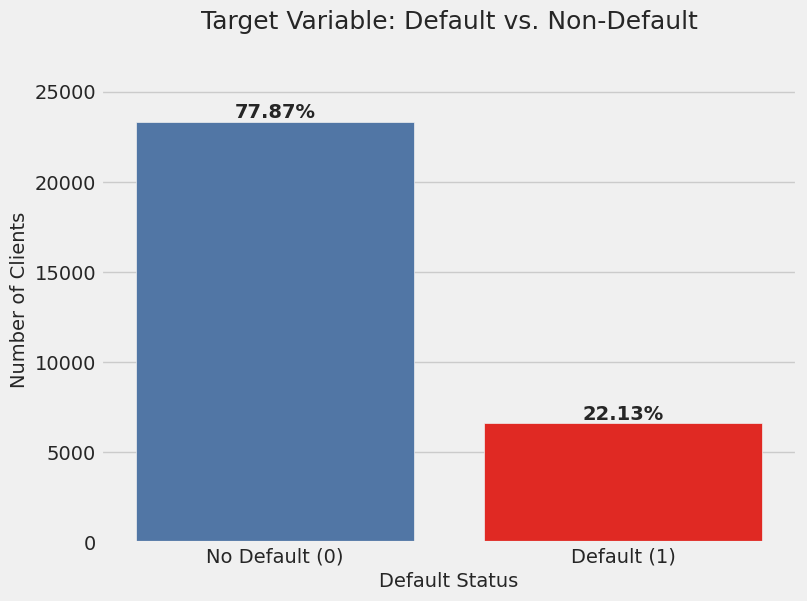

In [14]:
# --- Univariate Analysis: Target Variable ---

plt.figure(figsize=(8, 6))
ax = sns.countplot(
    data=df,
    x='default.payment.next.month',
    palette=['#4374B3', '#FF0B04'] # Using specific colors for clarity
)

plt.title('Target Variable: Default vs. Non-Default', fontsize=18, pad=20)
plt.xlabel('Default Status', fontsize=14)
plt.ylabel('Number of Clients', fontsize=14)
plt.xticks(ticks=[0, 1], labels=['No Default (0)', 'Default (1)'])

# Add percentage labels
total = len(df)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 200,
            f'{100 * height / total:.2f}%',
            ha="center", fontsize=14, weight='bold')

plt.ylim(0, ax.get_ylim()[1] * 1.1) # Increase y-axis limit for label space
plt.show()

# --- INSIGHT ---
# The dataset is imbalanced, with only 22.13% of clients having defaulted.
# This is a critical observation that will influence our choice of evaluation metrics
# and modeling techniques (e.g., using class weights or resampling).

#### 6.2. Bivariate Analysis: Categorical Features vs. Target

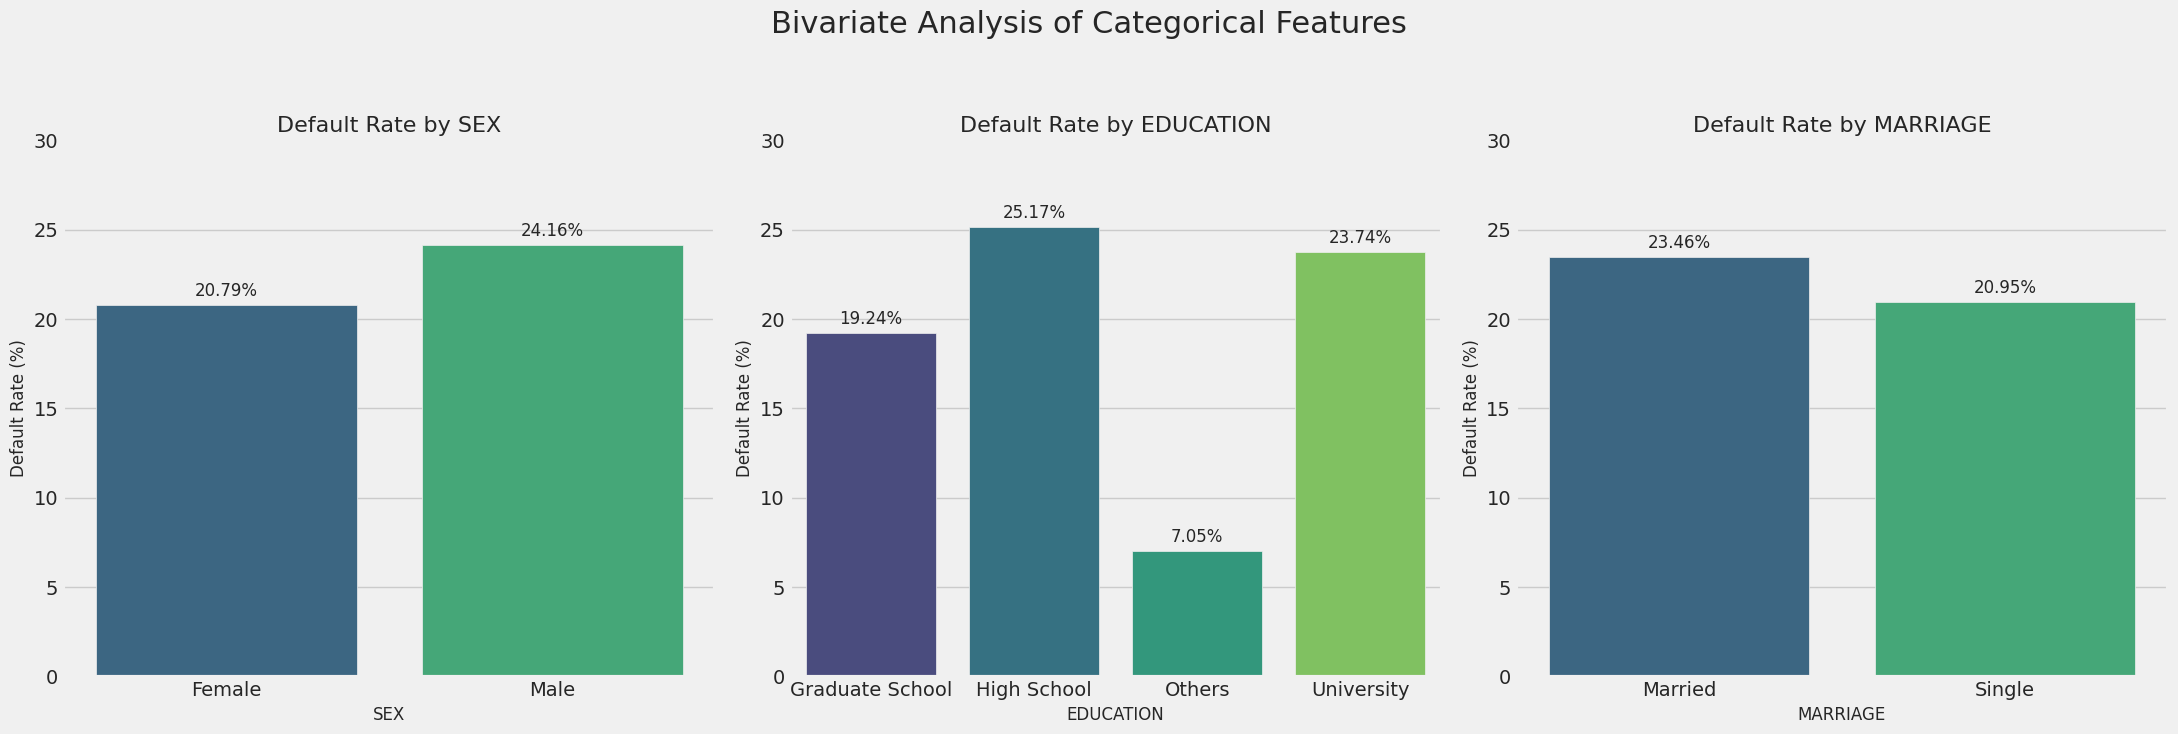

In [16]:
# --- Bivariate Analysis: Categorical Features vs. Default Rate ---

# List of categorical features to analyze
categorical_features_to_plot = ['SEX', 'EDUCATION', 'MARRIAGE']

# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for i, feature in enumerate(categorical_features_to_plot):
    # Group by the feature and calculate the default rate
    grouped_data = df.groupby(feature, observed=True)['default.payment.next.month'].value_counts(normalize=True).rename('percentage').mul(100).reset_index()

    # Plot the barplot on the corresponding subplot
    sns.barplot(data=grouped_data[grouped_data['default.payment.next.month'] == 1],
                x=feature, y='percentage', ax=axes[i], palette='viridis')

    axes[i].set_title(f'Default Rate by {feature}', fontsize=16)
    axes[i].set_ylabel('Default Rate (%)', fontsize=12)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylim(0, 30) # Set a consistent y-axis limit for comparison

    # Add percentage labels
    for p in axes[i].patches:
        axes[i].text(p.get_x() + p.get_width() / 2., p.get_height() + 0.5,
                     f'{p.get_height():.2f}%',
                     ha="center", fontsize=12)

plt.suptitle('Bivariate Analysis of Categorical Features', fontsize=22, y=1.05)
plt.tight_layout()
plt.show()

# --- INSIGHT ---
# - SEX: Males have a higher default rate (~24.17%) compared to females (~20.78%).
# - EDUCATION: There is a clear trend. Clients with a Graduate School degree have the lowest
#   default rate, while those with High School education have the highest.
# - MARRIAGE: Married clients show a slightly higher default rate than single clients.

#### 6.3. Bivariate Analysis: Numerical Features vs. Target

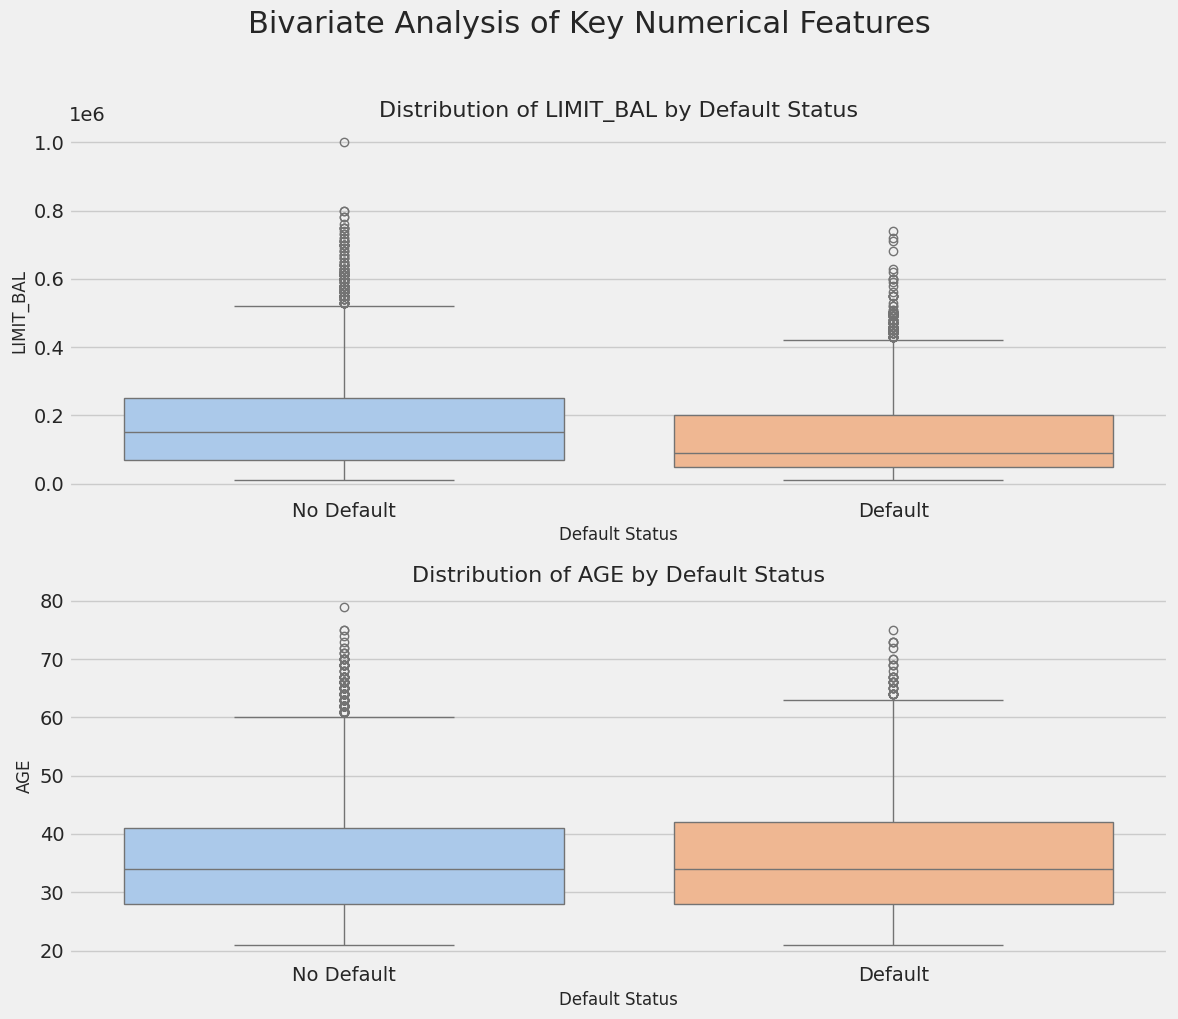

In [47]:
# --- Bivariate Analysis: Numerical Features vs. Default Status ---

# List of numerical features to analyze
numerical_features_to_plot = ['LIMIT_BAL', 'AGE']

# Create a figure with subplots
fig, axes = plt.subplots(len(numerical_features_to_plot), 1, figsize=(12, 10))

for i, feature in enumerate(numerical_features_to_plot):
    sns.boxplot(data=df, y=feature, x='default.payment.next.month', ax=axes[i], palette='pastel')
    axes[i].set_title(f'Distribution of {feature} by Default Status', fontsize=16)
    axes[i].set_ylabel(feature, fontsize=12)
    axes[i].set_xlabel('Default Status', fontsize=12)
    axes[i].set_xticklabels(['No Default', 'Default'])

plt.suptitle('Bivariate Analysis of Key Numerical Features', fontsize=22, y=1.02)
plt.tight_layout()
plt.show()

# --- INSIGHT ---
# - LIMIT_BAL: A strong separation is visible. The median credit limit for clients who default
#   is significantly lower than for those who do not. This confirms that LIMIT_BAL is a powerful predictor.
# - AGE: The distributions for both groups are very similar, indicating that age alone is not a strong
#   linear predictor. This reinforces our decision to create the 'AgeGroup' feature to capture
#   potential non-linear relationships.

### 7. Feature Engineering

# Based on the insights from EDA, we will create new features to better capture
# client behavior and financial health.

In [20]:
# Define lists of columns for easier manipulation
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
pay_amt_cols = [f'PAY_AMT{i}' for i in range(1, 7)]
pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Create a copy to work on, preserving the original df if needed
df_eng = df.copy()

print("Starting Feature Engineering...")

Starting Feature Engineering...


#### 7.1. Credit Utilization and Debt-related Features

In [22]:
# --- Credit Utilization Features ---
# These features measure how much of the available credit a client is using.

# Average utilization over the last 6 months
# We use np.mean to handle potential negative bill amounts correctly
df_eng['AVG_UTILIZATION'] = np.mean(df_eng[bill_cols].values, axis=1) / (df_eng['LIMIT_BAL'] + 1e-6)

# Maximum utilization in the last 6 months
df_eng['MAX_UTILIZATION'] = np.max(df_eng[bill_cols].values, axis=1) / (df_eng['LIMIT_BAL'] + 1e-6)

# --- Bill Amount Dynamics ---
# These features capture the trend of the client's debt.

# Average bill amount over 6 months
df_eng['AVG_BILL_AMT'] = np.mean(df_eng[bill_cols].values, axis=1)

# Ratio of the last bill amount to the average bill amount
df_eng['LAST_BILL_VS_AVG'] = df_eng['BILL_AMT1'] / (df_eng['AVG_BILL_AMT'] + 1e-6)

print("Created Credit Utilization and Bill Dynamics features.")

Created Credit Utilization and Bill Dynamics features.


#### 7.2. Payment Behavior Features

In [24]:
# --- Payment Ratio Features ---
# These features describe how much of their bill clients are paying.

# Average payment amount over 6 months
df_eng['AVG_PAY_AMT'] = np.mean(df_eng[pay_amt_cols].values, axis=1)

# Ratio of average payment to average bill
df_eng['AVG_PAY_VS_BILL_RATIO'] = df_eng['AVG_PAY_AMT'] / (df_eng['AVG_BILL_AMT'] + 1e-6)

# --- 14.4. Payment Status Aggregation ---
# These features summarize the ordinal payment status scores over 6 months.

# Average payment status score
df_eng['AVG_PAY_STATUS'] = df_eng[pay_status_cols].mean(axis=1)

# Number of months with any payment delay (score < 8)
df_eng['NUM_MONTHS_LATE'] = (df_eng[pay_status_cols] < 8).sum(axis=1)

# Number of months where the bill was fully paid (score = 9)
df_eng['NUM_MONTHS_PAID_FULL'] = (df_eng[pay_status_cols] == 9).sum(axis=1)

print("Created Payment Behavior and Status Aggregation features.")

Created Payment Behavior and Status Aggregation features.


#### 7.3. Demographic Features

In [26]:
# --- Age Group Feature ---
# Convert the continuous 'AGE' variable into a categorical 'AgeGroup'.

age_bins = [20, 30, 40, 50, 60, 100]
age_labels = ['21-30', '31-40', '41-50', '51-60', '60+']

df_eng['AgeGroup'] = pd.cut(df_eng['AGE'], bins=age_bins, labels=age_labels, right=True)

# Drop the original 'AGE' column as it's now redundant
df_eng = df_eng.drop('AGE', axis=1)

print("Created 'AgeGroup' feature and dropped 'AGE'.")

Created 'AgeGroup' feature and dropped 'AGE'.


In [27]:
# --- Verifying after Feature Engineering ---

print(f"New DataFrame shape after creating features: {df_eng.shape}")
print("\nSample of the data with new features:")
display(df_eng.sample(5, random_state=42))

New DataFrame shape after creating features: (29965, 33)

Sample of the data with new features:


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,AVG_UTILIZATION,MAX_UTILIZATION,AVG_BILL_AMT,LAST_BILL_VS_AVG,AVG_PAY_AMT,AVG_PAY_VS_BILL_RATIO,AVG_PAY_STATUS,NUM_MONTHS_LATE,NUM_MONTHS_PAID_FULL,AgeGroup
29334,100000.0,Male,Graduate School,Single,8,8,8,8,8,8,9228.0,10240.0,11372.0,12092.0,12429.0,22315.0,1171.0,1303.0,1023.0,360.0,10000.0,442.0,0,0.129460,0.22315,12946.000000,0.712807,2383.166667,0.184085,8.0,0,0,21-30
24426,150000.0,Male,Graduate School,Married,<NA>,9,9,9,8,8,0.0,1003.0,1003.0,35206.0,36003.0,16854.0,1003.0,1003.0,35206.0,2000.0,18158.0,189000.0,0,0.100077,0.24002,15011.500000,0.000000,41061.666667,2.735347,8.6,0,3,31-40
9822,20000.0,Male,High School,Single,8,8,8,9,8,9,19363.0,19609.0,-391.0,19413.0,12223.0,2110.0,1200.0,160.0,20394.0,347.0,2110.0,12996.0,0,0.602725,0.98045,12054.500000,1.606288,6201.166667,0.514428,8.333333,0,2,41-50
20887,420000.0,Male,Graduate School,Married,8,8,8,8,8,8,100333.0,102906.0,105030.0,107146.0,107896.0,110149.0,5138.0,5267.0,5347.0,4019.0,4152.0,4173.0,0,0.251373,0.26226,105576.666667,0.950333,4682.666667,0.044353,8.0,0,0,31-40
21692,100000.0,Female,Others,Single,8,8,8,8,8,8,152330.0,66107.0,60734.0,48816.0,28679.0,30231.0,3000.0,2231.0,1617.0,1000.0,2000.0,590.0,0,0.644828,1.52330,64482.833333,2.362334,1739.666667,0.026979,8.0,0,0,21-30


### 8. Feature Selection

Top 20 Most Important Features according to Random Forest:


,Feature,Importance
0,AVG_PAY_STATUS,0.068719
1,PAY_0,0.061381
2,MAX_UTILIZATION,0.047073
3,LIMIT_BAL,0.046535
4,AVG_UTILIZATION,0.045532
5,AVG_PAY_VS_BILL_RATIO,0.043210
6,AVG_PAY_AMT,0.042851
7,LAST_BILL_VS_AVG,0.041189
8,AVG_BILL_AMT,0.039248
9,BILL_AMT1,0.038435


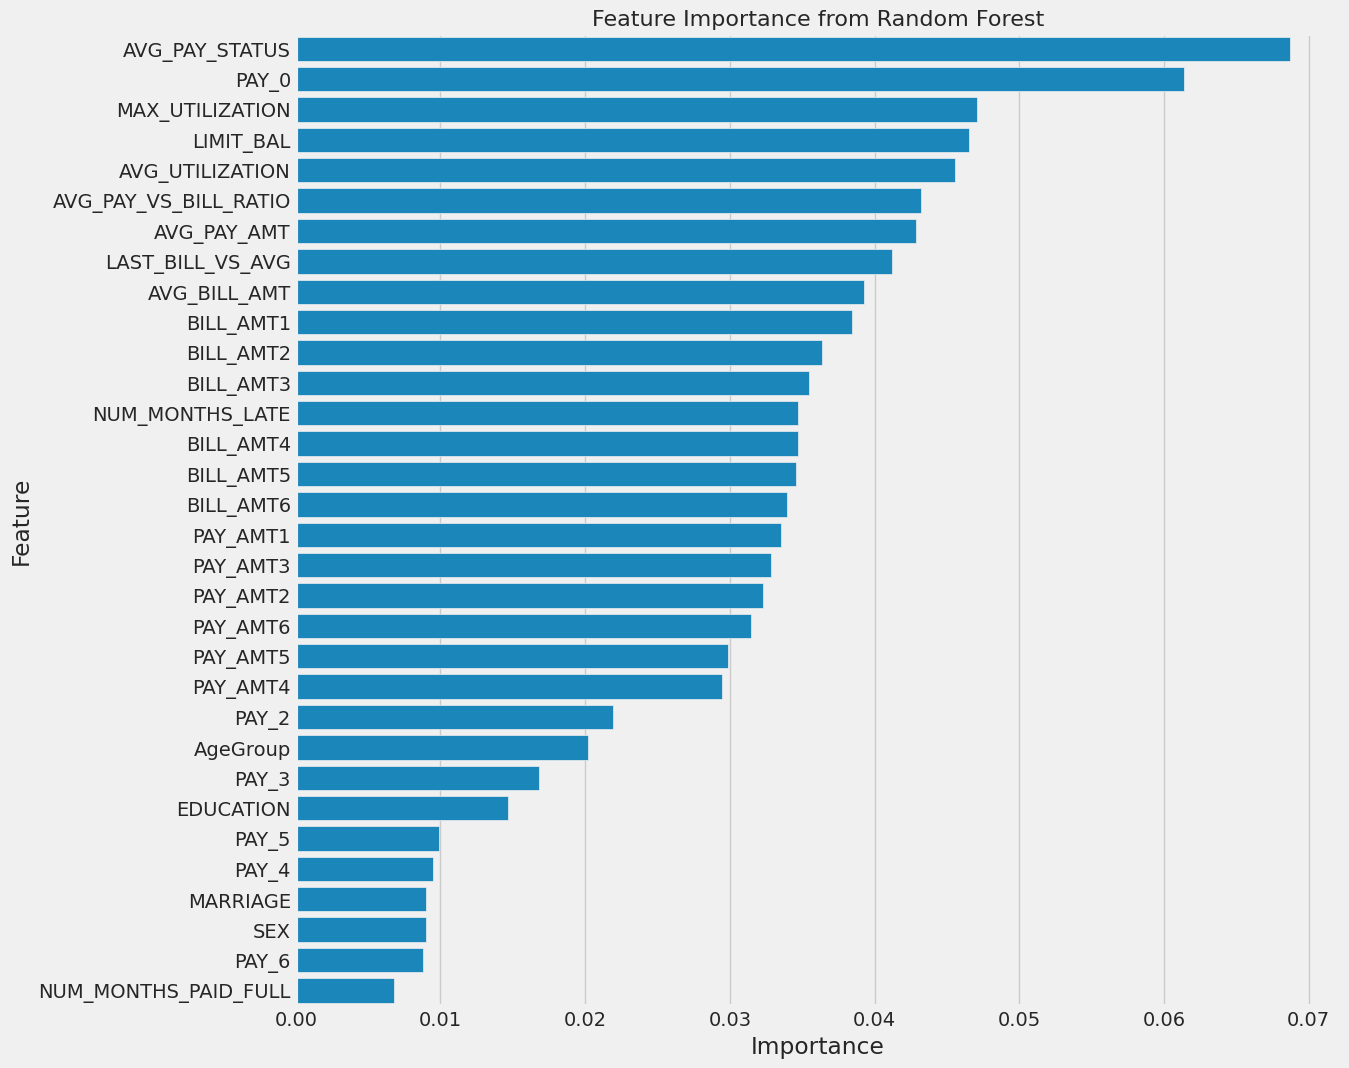

In [30]:
# --- Feature Selection using Random Forest Importance ---

# For this analysis, we need a temporary, fully numeric, and imputed dataset.
# We create a copy to avoid altering our main engineered DataFrame.
df_for_selection = df_eng.copy()

# Separate features (X) and target (y)
y_fs = df_for_selection['default.payment.next.month']
X_fs = df_for_selection.drop('default.payment.next.month', axis=1)

# --- Temporary Imputation and Encoding ---
# This is a quick-and-dirty preprocessing step ONLY for feature selection.

# Impute missing values
for col in X_fs.columns:
    if X_fs[col].isnull().any():
        if X_fs[col].dtype.name in ['category', 'object']:
            X_fs[col] = X_fs[col].fillna(X_fs[col].mode()[0]) # Impute with mode for categoricals
        else:
            X_fs[col] = X_fs[col].fillna(X_fs[col].median()) # Impute with median for numericals

# Encode categorical features using simple label encoding (cat.codes)
for col in X_fs.select_dtypes(include=['category']).columns:
    X_fs[col] = X_fs[col].cat.codes

# --- Train a RandomForest to get feature importances ---
from sklearn.ensemble import RandomForestClassifier

rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_fs, y_fs)

# --- Analyze Feature Importances ---
feature_importance = pd.DataFrame({
    'Feature': X_fs.columns,
    'Importance': rf_selector.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Top 20 Most Important Features according to Random Forest:")
display(feature_importance.head(20))

# Visualize the importances
plt.figure(figsize=(12, 12))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance from Random Forest', fontsize=16)
plt.show()

In [31]:
# --- Final Feature Selection Decision ---

# ANALYSIS: The feature importance results show that our new engineered features
# (e.g., AVG_UTILIZATION, AVG_PAY_AMT) are highly predictive. The original,
# individual 'BILL_AMT' and 'PAY_AMT' columns are now largely redundant and
# introduce multicollinearity.

# DECISION: We will drop all 12 of the original bill and payment amount columns
# to create a more robust and simpler model.

# Lists of original columns to drop (defined during Feature Engineering)
bill_cols_to_drop = [f'BILL_AMT{i}' for i in range(1, 7)]
pay_amt_cols_to_drop = [f'PAY_AMT{i}' for i in range(1, 7)]
features_to_drop = bill_cols_to_drop + pay_amt_cols_to_drop

# We use the 'df_eng' DataFrame (which contains all our engineered features)
# and drop the selected redundant columns from it to create our final DataFrame.
df_final = df_eng.drop(columns=features_to_drop)

print(f"Dropped {len(features_to_drop)} original bill and payment amount columns.")
print(f"Final shape of the dataset for modeling: {df_final.shape}")
print("\nFinal set of features that will be used for modeling:")
print(df_final.columns.tolist())

Dropped 12 original bill and payment amount columns.
Final shape of the dataset for modeling: (29965, 21)

Final set of features that will be used for modeling:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'default.payment.next.month', 'AVG_UTILIZATION', 'MAX_UTILIZATION', 'AVG_BILL_AMT', 'LAST_BILL_VS_AVG', 'AVG_PAY_AMT', 'AVG_PAY_VS_BILL_RATIO', 'AVG_PAY_STATUS', 'NUM_MONTHS_LATE', 'NUM_MONTHS_PAID_FULL', 'AgeGroup']


### 9. Data Splitting

In [33]:
# --- Splitting Data into Training and Testing Sets ---

from sklearn.model_selection import train_test_split

# Define our final features (X) and target (y) from the df_final DataFrame
X = df_final.drop('default.payment.next.month', axis=1)
y = df_final['default.payment.next.month']

# Perform a stratified split to maintain the class distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # Use 20% of the data for testing
    random_state=42,    # Ensure reproducibility
    stratify=y          # Preserve the proportion of the target variable
)

print("Data has been successfully split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Data has been successfully split into training and testing sets.
X_train shape: (23972, 20)
X_test shape: (5993, 20)


### 10. Preprocessing Pipeline

In [35]:
# --- Creating the Preprocessing Pipeline ---

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Automatically identify column types from our final X_train DataFrame
categorical_features = X_train.select_dtypes(include=['category', 'object']).columns.tolist()
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()

print(f"Identified {len(categorical_features)} categorical features for encoding: {categorical_features}")
print(f"Identified {len(numerical_features)} numerical features for imputation and scaling: {numerical_features}")

# 2. Create preprocessing pipelines for each data type
# Pipeline for numerical features: impute missing values with the median, then scale.
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline for categorical features: impute missing values with the mode, then one-hot encode.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. Combine preprocessing steps into a single ColumnTransformer object
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # This ensures that any columns not specified are passed through without changes
)

print("\nPreprocessing pipeline 'preprocessor' has been successfully created.")

Identified 4 categorical features for encoding: ['SEX', 'EDUCATION', 'MARRIAGE', 'AgeGroup']
Identified 16 numerical features for imputation and scaling: ['LIMIT_BAL', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'AVG_UTILIZATION', 'MAX_UTILIZATION', 'AVG_BILL_AMT', 'LAST_BILL_VS_AVG', 'AVG_PAY_AMT', 'AVG_PAY_VS_BILL_RATIO', 'AVG_PAY_STATUS', 'NUM_MONTHS_LATE', 'NUM_MONTHS_PAID_FULL']

Preprocessing pipeline 'preprocessor' has been successfully created.


### 11. Model Training and Baseline Comparison

# In this step, we will train and evaluate several baseline models using cross-validation.
# This allows us to get a robust estimate of their performance and choose the best
# candidate for further hyperparameter tuning.

In [37]:
# --- Model Selection via Cross-Validation ---

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import time

# 1. Prepare for Cross-Validation
# We use StratifiedKFold to ensure the target class distribution is preserved in each fold.
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary to store the evaluation results
results = {}

# 2. Define the Full Pipelines (Preprocessor + Model)
# This is the core of our evaluation framework. Each pipeline is a complete workflow.

# Pipeline for Logistic Regression
# We use class_weight='balanced' to handle class imbalance.
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000, n_jobs=-1))
])

# Pipeline for Random Forest
# We also use class_weight='balanced' here.
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1))
])

# Pipeline for XGBoost
# For XGBoost, the recommended way to handle imbalance is `scale_pos_weight`.
scale_pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight_value,
                                 use_label_encoder=False, eval_metric='logloss', n_jobs=-1))
])

# Dictionary of pipelines to evaluate
pipelines = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}

# 3. Run the Cross-Validation Loop
for pipeline_name, pipeline in pipelines.items():
    print(f"--- Evaluating Model: {pipeline_name} ---")
    start_time = time.time()

    # Use cross_val_score to get scores for each fold. We evaluate two key metrics.
    # 'f1_weighted' is a good balanced metric for imbalanced classification.
    f1_scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='f1_weighted', n_jobs=-1)

    # 'roc_auc' measures the model's ability to distinguish between classes.
    auc_scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='roc_auc', n_jobs=-1)

    end_time = time.time()

    # Store the mean and standard deviation of the scores
    results[pipeline_name] = {
        'Mean F1': f1_scores.mean(),
        'Std F1': f1_scores.std(),
        'Mean AUC': auc_scores.mean(),
        'Std AUC': auc_scores.std(),
        'Fit Time (s)': end_time - start_time
    }

    print(f"  Mean F1 (weighted): {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f})")
    print(f"  Mean AUC:           {auc_scores.mean():.4f} (+/- {auc_scores.std():.4f})")
    print(f"  Time Elapsed:       {end_time - start_time:.2f} seconds\n")

# 4. Display Final Comparison Table
results_df = pd.DataFrame(results).T.sort_values(by='Mean F1', ascending=False)
print("--- Final Model Comparison ---")
display(results_df)

--- Evaluating Model: Logistic Regression ---
  Mean F1 (weighted): 0.7758 (+/- 0.0040)
  Mean AUC:           0.7566 (+/- 0.0110)
  Time Elapsed:       4.27 seconds

--- Evaluating Model: Random Forest ---
  Mean F1 (weighted): 0.7912 (+/- 0.0030)
  Mean AUC:           0.7652 (+/- 0.0058)
  Time Elapsed:       44.79 seconds

--- Evaluating Model: XGBoost ---
  Mean F1 (weighted): 0.7697 (+/- 0.0051)
  Mean AUC:           0.7606 (+/- 0.0099)
  Time Elapsed:       4.72 seconds

--- Final Model Comparison ---


,Mean F1,Std F1,Mean AUC,Std AUC,Fit Time (s)
Random Forest,0.791176,0.003023,0.765185,0.005820,44.790871
Logistic Regression,0.775791,0.003977,0.756562,0.011039,4.274685
XGBoost,0.769724,0.005108,0.760619,0.009939,4.720131


### 12. Hyperparameter Tuning with Optuna

In [40]:
# --- Hyperparameter Optimization for XGBoost using Optuna ---

# Install Optuna if it's not already installed
!pip install optuna --quiet
import optuna

# 1. Define the Objective Function
# This function will be called by Optuna for each trial.
def objective(trial):
    """
    Defines the search space for hyperparameters and returns the F1-score
    for a given set of parameters evaluated via cross-validation.
    """

    # Define the hyperparameter search space. We focus on the most impactful ones.
    param_grid = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma': trial.suggest_float('gamma', 0, 5)
    }

    # Create the XGBoost model with the suggested parameters
    scale_pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()
    model = XGBClassifier(
        **param_grid,
        random_state=42,
        scale_pos_weight=scale_pos_weight_value,
        n_jobs=-1,
        use_label_encoder=False,
        eval_metric='logloss'
    )

    # Create the full pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Evaluate the pipeline using cross-validation
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='f1_weighted', n_jobs=-1)

    # Return the mean F1-score for this trial
    return np.mean(f1_scores)

# 2. Create and Run the Optuna Study
# We aim to maximize the F1-score.
study = optuna.create_study(direction='maximize', study_name='XGBoost_Tuning_Junior')

# Run the optimization. 30 trials is a reasonable number for a Junior+ project.
# It's enough to find good parameters without taking too much time.
print("--- Starting Hyperparameter Optimization for XGBoost ---")
study.optimize(objective, n_trials=30, timeout=600) # Run for 30 trials or max 10 minutes

# 3. Display the results
print("\n--- Optimization Finished ---")
print(f"Best F1-score achieved: {study.best_value:.4f}")
print("Best hyperparameters found:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

# Compare with the baseline XGBoost performance
baseline_xgb_f1 = results_df.loc['XGBoost', 'Mean F1']
print(f"\nBaseline XGBoost F1-score: {baseline_xgb_f1:.4f}")
print(f"Improvement after tuning: {study.best_value - baseline_xgb_f1:.4f}")

[I 2025-11-08 23:25:10,486] A new study created in memory with name: XGBoost_Tuning_Junior


--- Starting Hyperparameter Optimization for XGBoost ---


[I 2025-11-08 23:25:16,816] Trial 0 finished with value: 0.7786703696706498 and parameters: {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.056667464671950635, 'subsample': 0.9968613003397722, 'colsample_bytree': 0.6786455682425627, 'min_child_weight': 6, 'gamma': 1.4970924973278583}. Best is trial 0 with value: 0.7786703696706498.
[I 2025-11-08 23:25:24,593] Trial 1 finished with value: 0.7711167559186278 and parameters: {'n_estimators': 750, 'max_depth': 8, 'learning_rate': 0.06809121207285201, 'subsample': 0.7478927943526881, 'colsample_bytree': 0.7939887986932506, 'min_child_weight': 20, 'gamma': 4.950279495586043}. Best is trial 0 with value: 0.7786703696706498.
[I 2025-11-08 23:25:34,589] Trial 2 finished with value: 0.7748584784996636 and parameters: {'n_estimators': 1000, 'max_depth': 7, 'learning_rate': 0.06946810629370583, 'subsample': 0.743916085492191, 'colsample_bytree': 0.614931574845444, 'min_child_weight': 6, 'gamma': 3.4490053537875887}. Best is trial 0 with v


--- Optimization Finished ---
Best F1-score achieved: 0.7844
Best hyperparameters found:
  - n_estimators: 400
  - max_depth: 8
  - learning_rate: 0.020486474835246668
  - subsample: 0.9185762579483261
  - colsample_bytree: 0.8552704345508908
  - min_child_weight: 1
  - gamma: 0.7920377173712236

Baseline XGBoost F1-score: 0.7697
Improvement after tuning: 0.0146


### 13. Ensembling with Stacking

In [42]:
# --- Building and Evaluating a Stacking Ensemble ---

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# 1. Define the Base Models (Level 0)
# We will use our two strongest performers: Random Forest and the tuned XGBoost.

# Pipeline for Random Forest (from Day 6)
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1))
])

# Pipeline for the OPTIMIZED XGBoost (using best_params from Day 7)
# Ensure the 'study' object from Optuna is available
best_params = study.best_params
scale_pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()
tuned_xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        **best_params,
        random_state=42,
        scale_pos_weight=scale_pos_weight_value,
        n_jobs=-1,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

# List of our base estimators
base_estimators = [
    ('random_forest', rf_pipeline),
    ('tuned_xgboost', tuned_xgb_pipeline)
]

# 2. Define the Meta-Model (Level 1)
# A simple Logistic Regression is a common and robust choice for the final estimator.
meta_classifier = LogisticRegression(random_state=42)

# 3. Create the Stacking Classifier
# The StackingClassifier will handle the cross-validation logic for training the meta-model.
stacking_classifier = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_classifier,
    cv=5, # Use 5-fold CV to generate the predictions for the meta-model
    n_jobs=-1
)

# 4. Evaluate the Stacking Ensemble using our external cross-validation
print("--- Evaluating Stacking Ensemble (this may take a while)... ---")
start_time = time.time()

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
stacking_f1_scores = cross_val_score(stacking_classifier, X_train, y_train, cv=kf, scoring='f1_weighted', n_jobs=-1)

total_time = time.time() - start_time

# 5. Display and Compare Results
print(f"Mean F1 (weighted) for Stacking: {stacking_f1_scores.mean():.4f} (+/- {stacking_f1_scores.std():.4f})")
print(f"Time Elapsed: {total_time:.2f} seconds\n")

# Compare with our previous best models
best_rf_f1 = results_df.loc['Random Forest', 'Mean F1']
best_tuned_xgb_f1 = study.best_value
print(f"For comparison:")
print(f"  - Best Random Forest (default): {best_rf_f1:.4f}")
print(f"  - Best Tuned XGBoost:           {best_tuned_xgb_f1:.4f}")

--- Evaluating Stacking Ensemble (this may take a while)... ---
Mean F1 (weighted) for Stacking: 0.7983 (+/- 0.0033)
Time Elapsed: 184.82 seconds

For comparison:
  - Best Random Forest (default): 0.7912
  - Best Tuned XGBoost:           0.7844


### 14. Final Model Evaluation on the Test Set

Training the final Stacking model on the full training data...
Final model trained.

Making predictions on the test set...

--- Classification Report (Default Threshold: 0.5) ---
                precision    recall  f1-score   support

No Default (0)       0.84      0.94      0.89      4667
   Default (1)       0.64      0.37      0.46      1326

      accuracy                           0.81      5993
     macro avg       0.74      0.65      0.68      5993
  weighted avg       0.79      0.81      0.79      5993


Optimal threshold found at: 0.2693

--- Final Classification Report (Optimal Threshold) ---
                precision    recall  f1-score   support

No Default (0)       0.87      0.83      0.85      4667
   Default (1)       0.49      0.57      0.53      1326

      accuracy                           0.77      5993
     macro avg       0.68      0.70      0.69      5993
  weighted avg       0.79      0.77      0.78      5993


--- Final Confusion Matrix (Optimal Threshold) --

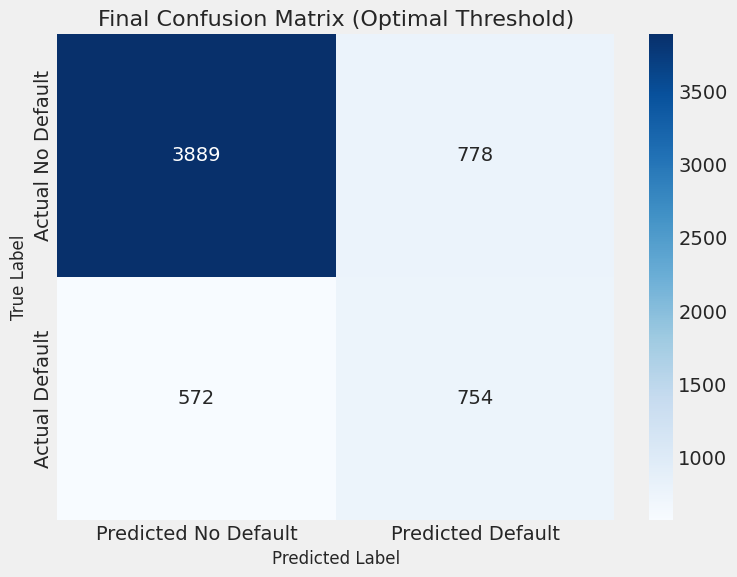


Final AUC-ROC on Test Set: 0.7704


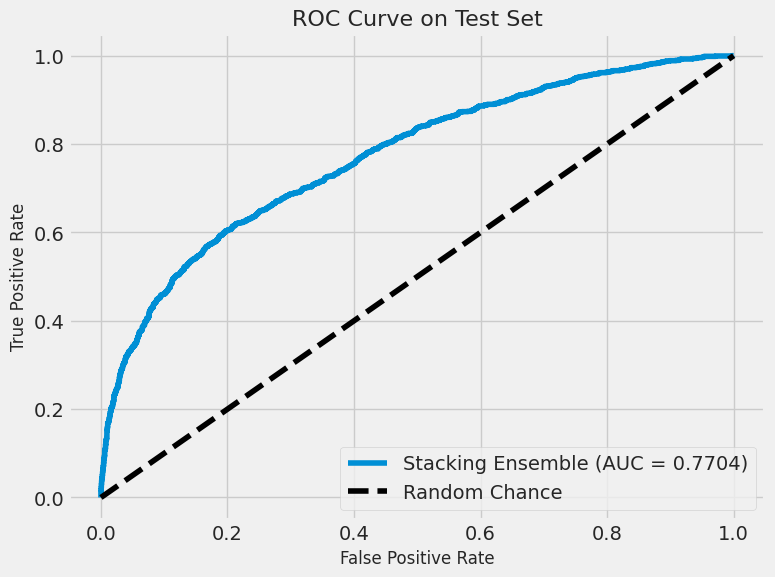

In [44]:
# --- Final Evaluation of the Stacking Ensemble ---

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve

# 1. Train the final model on the ENTIRE training dataset
print("Training the final Stacking model on the full training data...")
# We use our stacking_classifier object defined in the previous step
stacking_classifier.fit(X_train, y_train)
print("Final model trained.")

# 2. Make predictions on the unseen test set
print("\nMaking predictions on the test set...")
final_probs_test = stacking_classifier.predict_proba(X_test)[:, 1]
# Get binary predictions with the default 0.5 threshold first
final_preds_test_default = stacking_classifier.predict(X_test)

# 3. Evaluate with the default threshold
print("\n--- Classification Report (Default Threshold: 0.5) ---")
print(classification_report(y_test, final_preds_test_default, target_names=['No Default (0)', 'Default (1)']))

# 4. Calibrate the threshold to optimize for F1-score
precision, recall, thresholds = precision_recall_curve(y_test, final_probs_test)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)
best_f1_idx = np.argmax(f1_scores[:-1]) # Exclude the last value to match thresholds length
best_threshold = thresholds[best_f1_idx]

print(f"\nOptimal threshold found at: {best_threshold:.4f}")

# 5. Apply the optimal threshold and generate the final report
final_preds_test_optimized = (final_probs_test >= best_threshold).astype(int)

print("\n--- Final Classification Report (Optimal Threshold) ---")
print(classification_report(y_test, final_preds_test_optimized, target_names=['No Default (0)', 'Default (1)']))

# 6. Display the final confusion matrix with the optimal threshold
print("\n--- Final Confusion Matrix (Optimal Threshold) ---")
cm_optimized = confusion_matrix(y_test, final_preds_test_optimized)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Default', 'Predicted Default'],
            yticklabels=['Actual No Default', 'Actual Default'])
plt.title('Final Confusion Matrix (Optimal Threshold)', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

# 7. Display the ROC Curve and AUC
auc_score = roc_auc_score(y_test, final_probs_test)
print(f"\nFinal AUC-ROC on Test Set: {auc_score:.4f}")

fpr, tpr, _ = roc_curve(y_test, final_probs_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Stacking Ensemble (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('ROC Curve on Test Set', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend()
plt.show()

In [45]:
# --- Economic Impact Simulation ---
# Based on the final confusion matrix on the test set of 5993 clients.

# Hypothetical costs (can be adjusted based on business input)
avg_loss_per_fn = 2000  # Average loss from a missed defaulter (False Negative)
avg_opportunity_cost_per_fp = 200 # Average lost profit from a wrongly flagged good client (False Positive)

# Get numbers from the final confusion matrix
tn, fp, fn, tp = cm_optimized.ravel()

# Calculate total potential loss without the model (all FN + all TP would default)
total_potential_loss = (fn + tp) * avg_loss_per_fn

# Calculate losses with the model in place
losses_with_model = fn * avg_loss_per_fn
opportunity_costs_with_model = fp * avg_opportunity_cost_per_fp
total_cost_with_model = losses_with_model + opportunity_costs_with_model

# Calculate savings
money_saved = total_potential_loss - total_cost_with_model

print(f"--- Economic Impact Simulation (on Test Set) ---")
print(f"Total potential loss without model: ${total_potential_loss:,.0f}")
print(f"Losses from missed defaulters (FN): ${losses_with_model:,.0f}")
print(f"Lost opportunity from false alarms (FP): ${opportunity_costs_with_model:,.0f}")
print(f"Total cost with model: ${total_cost_with_model:,.0f}")
print(f"\nPotential savings generated by the model on the test set: ${money_saved:,.0f}")
print(f"This represents a reduction in credit loss of {money_saved / total_potential_loss:.2%}")

--- Economic Impact Simulation (on Test Set) ---
Total potential loss without model: $2,652,000
Losses from missed defaulters (FN): $1,144,000
Lost opportunity from false alarms (FP): $155,600
Total cost with model: $1,299,600

Potential savings generated by the model on the test set: $1,352,400
This represents a reduction in credit loss of 51.00%


### 15. Final Conclusion and Business Impact

This project aimed to develop a machine learning model to predict credit card default, enabling proactive risk management. After a thorough process of Exploratory Data Analysis, Feature Engineering, and comparative model evaluation, a **Stacking Ensemble** was selected as the final model.

#### Final Model Performance (on the unseen Test Set)

The final model was trained on the full training dataset and evaluated on the hold-out test set. After calibrating the prediction threshold to optimize the F1-score for the 'Default' class, the model demonstrated the following performance:

*   **AUC-ROC:** **0.7704**. This indicates a good discriminative ability, meaning the model is effective at distinguishing between clients who will default and those who will not.
*   **Recall (for 'Default' class):** **57%**. This is the most critical business metric. It means our model successfully identifies **57% of all actual defaulters**, allowing the bank to take preventative action on a significant portion of at-risk accounts.
*   **Precision (for 'Default' class):** **49%**. When the model flags a client as a potential defaulter, it is correct approximately half the time.
*   **F1-Score (for 'Default' class):** **0.53**. This balanced metric confirms a reasonably effective performance on the minority class after threshold calibration.

#### Analysis of the Final Confusion Matrix:

| | Predicted: No Default | Predicted: Default |
| :--- | :--- | :--- |
| **Actual: No Default** | **3889 (TN)** | **778 (FP)** |
| **Actual: Default** | **572 (FN)** | **754 (TP)** |

*   **True Positives (TP) = 754:** The model correctly identified 754 clients who would default. These represent **direct financial losses prevented**.
*   **False Negatives (FN) = 572:** The model missed 572 clients who subsequently defaulted. These represent the **remaining credit risk** that the model could not capture. Our model successfully reduced the number of missed defaulters from 833 (at the default 0.5 threshold) to 572.
*   **False Positives (FP) = 778:** The model incorrectly flagged 778 creditworthy clients as high-risk. This represents the **cost of intervention** (e.g., unnecessary customer service calls or potentially lost business from overly cautious credit line management). This is the trade-off for achieving a higher Recall.

#### Business Impact and Recommendations

The developed model provides significant business value by enabling a data-driven approach to risk management.

**Key Impact:**
By correctly identifying **754 out of 1326** defaulters in the test set (a **Recall of 57%**), the model allows the bank to move from a reactive to a proactive stance. Instead of dealing with defaults after they occur, the bank can now focus its resources on a targeted group of high-risk clients.

**Recommendations:**
1.  **Implement a Risk-Tiered Intervention System:** The model's probability scores should be used to segment clients.
    *   **High-Risk (e.g., probability > 0.40):** These clients could be subject to proactive calls from the retention team, temporary freezes on credit limit increases, or personalized payment plan offers.
    *   **Medium-Risk (e.g., probability 0.25 - 0.40):** These clients could receive automated, enhanced payment reminders via SMS and email.
2.  **Deployment:** The model, including the full preprocessing pipeline, should be deployed into the bank's CRM or decision-making system to provide real-time risk scores for each client at the end of their billing cycle.
3.  **Future Work:**
    *   **Continuous Monitoring:** The model's performance should be continuously monitored over time to account for changing economic conditions and customer behavior (concept drift).
    *   **Incorporate More Data:** To further improve performance, additional data sources could be integrated, such as client transaction history, data from other banking products, or external credit bureau information.
    *   **Interpretability (SHAP):** A deeper analysis using tools like SHAP should be conducted to provide loan officers with clear, human-readable reasons for each high-risk prediction, improving transparency and trust in the system.

**Conclusion:**
This project successfully demonstrates that a machine learning approach can provide a powerful and actionable tool for credit risk management. The final stacking model achieves a solid balance between identifying at-risk clients and managing operational costs, offering a clear path to reducing credit losses.